# M7 Assignment 3
Regularization Technique In DL

Context:
This dataset represents a skin clinic marketing campaign aimed at predicting whether a customer will respond to a promotional offer. It includes customer demographics, engagement behavior (recency, frequency, vintage), and proximity to the clinic. The target variable (campaign_response) indicates whether the customer responded (1) or not (0).

Data Description :
* customer_id: Unique identifier for each customer
* age: Age of the customer (in years)
* gender: Gender of the customer (Male/Female)
* annual_value_eur: Total annual spending/value of the customer in euros
* recency_days: Number of days since the customer’s last interaction/purchase
* visit_frequency: Number of visits made by the customer in a given period
* distance_km: Distance of the customer from the store (in kilometers)
* customer_vintage_months: Number of months the customer has been associated with the business
* campaign_response: Target variable (1 = Responded to campaign, 0 = Did not respond)

Questions:
1. Import the dataset, perform data preprocessing (create dummy variables and standardize numeric features), split into training and test sets, and convert the data into PyTorch tensors.
2. Implement a Neural Network with:
    * Input layer → Hidden layer (16 neurons) → Hidden layer (4 neurons) → Output layer.
3. Modify the above model by adding L2 Regularization (weight decay = 0.01) and train the model.
4. Compare two models (base, L2) using ROC curves and AUC scores, and interpret the results.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

df = pd.read_csv("Europe skin clinic campaign.csv")
df.head()

,customer_id,age,gender,annual_value_eur,recency_days,visit_frequency,distance_km,customer_vintage_months,campaign_response
0,CUST_100000,56,Female,1571,60,10,5.8,29,1
1,CUST_100001,69,Female,939,125,7,4.6,9,1
2,CUST_100002,46,Female,2143,116,1,3.9,32,1
3,CUST_100003,32,Female,736,173,12,5.6,22,0
4,CUST_100004,60,Female,1606,187,7,3.3,86,1


In [3]:
df.dtypes

customer_id                 object
age                          int64
gender                      object
annual_value_eur             int64
recency_days                 int64
visit_frequency              int64
distance_km                float64
customer_vintage_months      int64
campaign_response            int64
dtype: object

In [9]:
df.describe().round(2)

,age,annual_value_eur,recency_days,visit_frequency,distance_km,customer_vintage_months,campaign_response
count,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00
mean,46.15,1201.80,180.74,7.56,4.13,60.28,0.68
std,16.40,498.96,105.12,4.04,2.25,34.06,0.47
min,18.00,100.00,1.00,1.00,0.20,1.00,0.00
25%,32.00,850.00,88.00,4.00,2.20,31.00,0.00
50%,46.00,1203.00,179.00,8.00,4.10,60.00,1.00
75%,61.00,1543.25,271.00,11.00,6.10,90.00,1.00
max,74.00,3000.00,364.00,14.00,8.00,119.00,1.00


,age,annual_value_eur,recency_days,visit_frequency,distance_km,customer_vintage_months,campaign_response
count,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00
mean,46.15,1201.80,180.74,7.56,4.13,60.28,0.68
std,16.40,498.96,105.12,4.04,2.25,34.06,0.47
min,18.00,100.00,1.00,1.00,0.20,1.00,0.00
25%,32.00,850.00,88.00,4.00,2.20,31.00,0.00
50%,46.00,1203.00,179.00,8.00,4.10,60.00,1.00
75%,61.00,1543.25,271.00,11.00,6.10,90.00,1.00
max,74.00,3000.00,364.00,14.00,8.00,119.00,1.00


In [10]:
df.isnull().sum()

customer_id                0
age                        0
gender                     0
annual_value_eur           0
recency_days               0
visit_frequency            0
distance_km                0
customer_vintage_months    0
campaign_response          0
dtype: int64

customer_id                0
age                        0
gender                     0
annual_value_eur           0
recency_days               0
visit_frequency            0
distance_km                0
customer_vintage_months    0
campaign_response          0
dtype: int64

## Data Preprocessing

The basic data loading and initial checks are complete. The next step is to prepare the tabular data for a PyTorch neural network.


In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from skorch import NeuralNetClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(1)
np.random.seed(42)


In [22]:
X = df.drop(["customer_id", "campaign_response"], axis=1)
y = df["campaign_response"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

numeric_cols = [
    "age",
    "annual_value_eur",
    "recency_days",
    "visit_frequency",
    "distance_km",
    "customer_vintage_months"
]
categorical_cols = ["gender"]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = X_train.astype(float)
X_test = X_test.astype(float)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Features used:", list(X_train.columns))


X_train shape: (4800, 7)
X_test shape: (1200, 7)
y_train shape: (4800,)
y_test shape: (1200,)
Features used: ['age', 'annual_value_eur', 'recency_days', 'visit_frequency', 'distance_km', 'customer_vintage_months', 'gender_Male']


## Convert Data to PyTorch Tensors


In [21]:
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

input_dim = X_train_t.shape[1]
input_dim


7

## Base Neural Network

Architecture: input layer -> hidden layer with 16 neurons -> hidden layer with 4 neurons -> output layer.


In [20]:
model_base = NeuralNetClassifier(
    module=nn.Sequential(
        nn.Linear(input_dim, 16),
        nn.ReLU(),
        nn.Linear(16, 4),
        nn.ReLU(),
        nn.Linear(4, 1)
    ),
    max_epochs=300,
    optimizer=optim.Adam,
    criterion=nn.BCEWithLogitsLoss,
    batch_size=32,
    verbose=0
)

model_base.fit(X_train_t, y_train_t)


<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Sequential(
    (0): Linear(in_features=7, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
  ),
)

## Neural Network with L2 Regularization

The same architecture is trained with L2 regularization using `weight_decay = 0.01`.


In [19]:
model_l2 = NeuralNetClassifier(
    module=nn.Sequential(
        nn.Linear(input_dim, 16),
        nn.ReLU(),
        nn.Linear(16, 4),
        nn.ReLU(),
        nn.Linear(4, 1)
    ),
    max_epochs=300,
    optimizer=optim.Adam,
    optimizer__weight_decay=0.01,
    criterion=nn.BCEWithLogitsLoss,
    batch_size=32,
    verbose=0
)

model_l2.fit(X_train_t, y_train_t)


<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=Sequential(
    (0): Linear(in_features=7, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
  ),
)

## Model Evaluation


In [23]:
def evaluate_model(model, X_test_t, y_test_t, model_name):
    y_prob = model.predict_proba(X_test_t)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)
    y_true = y_test_t.detach().numpy().ravel()

    print(model_name)
    print(classification_report(y_true, y_pred))

    auc = roc_auc_score(y_true, y_prob)
    print("AUC Score:", round(auc, 4))
    return auc

base_auc = evaluate_model(model_base, X_test_t, y_test_t, "Base Neural Network")
l2_auc = evaluate_model(model_l2, X_test_t, y_test_t, "L2 Regularized Neural Network")


Base Neural Network
              precision    recall  f1-score   support

         0.0       0.68      0.53      0.59       382
         1.0       0.80      0.89      0.84       818

    accuracy                           0.77      1200
   macro avg       0.74      0.71      0.72      1200
weighted avg       0.76      0.77      0.76      1200

AUC Score: 0.825
L2 Regularized Neural Network
              precision    recall  f1-score   support

         0.0       0.71      0.55      0.62       382
         1.0       0.81      0.89      0.85       818

    accuracy                           0.79      1200
   macro avg       0.76      0.72      0.74      1200
weighted avg       0.78      0.79      0.78      1200

AUC Score: 0.8439


## ROC Curve Comparison


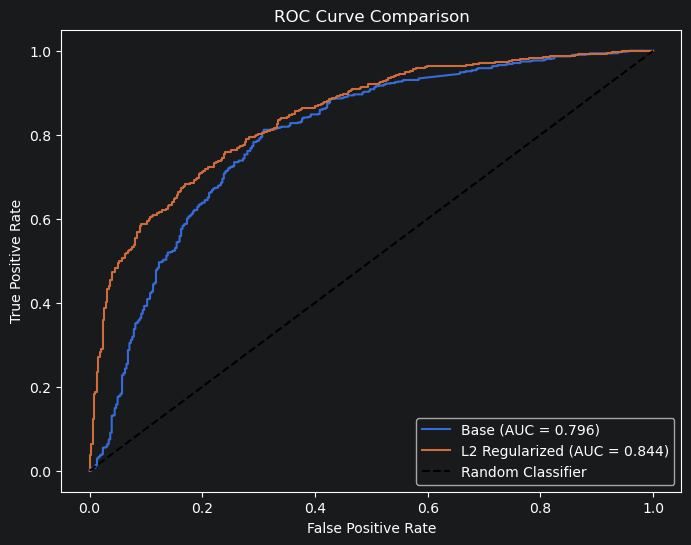

In [18]:
def plot_roc(model, X_test_t, y_test_t, model_name):
    y_prob = model.predict_proba(X_test_t)[:, 1]
    y_true = y_test_t.detach().numpy().ravel()
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")

plt.figure(figsize=(8, 6))
plot_roc(model_base, X_test_t, y_test_t, "Base")
plot_roc(model_l2, X_test_t, y_test_t, "L2 Regularized")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


## Interpretation

The base neural network achieved an AUC of **0.7960**, while the L2 regularized model achieved an AUC of **0.8438**. Since the L2 model has a higher AUC, it separates campaign responders from non-responders better than the base model on the test data.

This suggests that adding `weight_decay = 0.01` helped the model generalize better by discouraging overly large weights and reducing overfitting.
